## Basic Info

In [23]:
import pandas as pd

df = pd.read_csv("/Users/apple/6_Major_Projects/MLOpsChurnPipeline/data/raw/Telco-Customer-Churn.csv")

print(df.head())
print(df.shape)
print(df.columns)
print(df.info())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

Observation:
- The dataset contains 7043 rows and 21 columns.
- There are 18 categorical features and 3 numerical features.
- The target variable is 'Churn'.
- The 'customerID' column is a unique identifier and does not contribute to prediction, so it will be removed during feature engineering.
- The 'TotalCharges' column has incorrect datatype (object) and needs to be converted to numeric.

## Missing Values

In [24]:
### Check missing values
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [25]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


Observation:
- There were no missing values initially, but after converting 'TotalCharges' to numeric, 11 missing values were found.
- This indicates that some values were blank strings and not detected as missing initially.
- Since the number of missing values is very small (<1%), the rows will be dropped instead of imputing values.

In [26]:
df.dropna(inplace=True)

In [27]:
print(df.shape)

(7032, 21)


## Target Variable(Class Imbalance)

In [28]:
## Check imbalance
print(df["Churn"].value_counts())

Churn
No     5163
Yes    1869
Name: count, dtype: int64


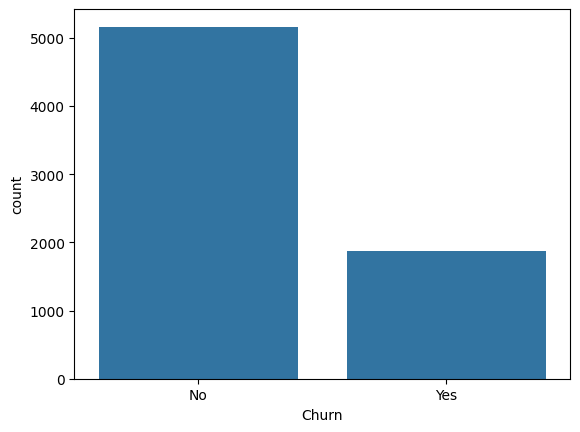

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.show()

Observation:
- The dataset is imbalanced.
- 73% of customers did not churn, while 27% of customers churned.
- Accuracy is not a reliable metric for this dataset.
- Evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC will be used.
- Class imbalance will be handled using class weights or scale_pos_weight.

## Numerical Features

In [30]:
## Numerical Features 
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


Observation:
- The 'tenure' feature shows that many customers have low tenure, indicating new customers are more likely to churn.
- 'MonthlyCharges' shows that customers with higher monthly charges tend to churn more.
- 'TotalCharges' is right-skewed and highly correlated with tenure and MonthlyCharges.
- Feature scaling will be required for numerical features.

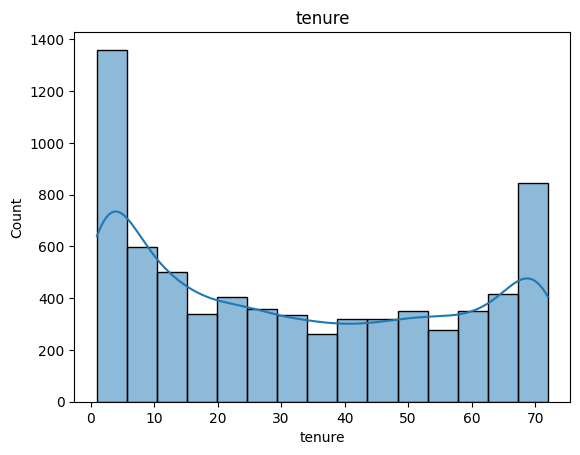

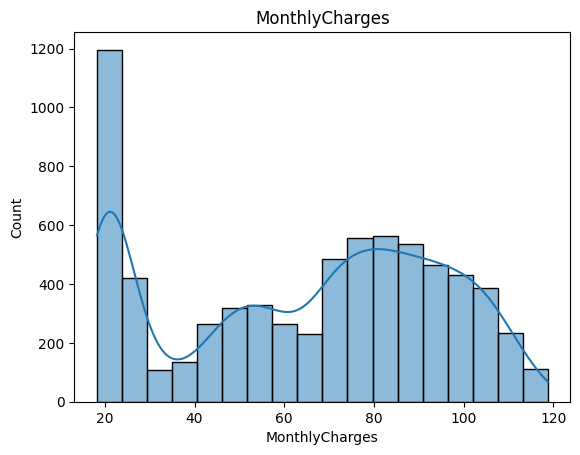

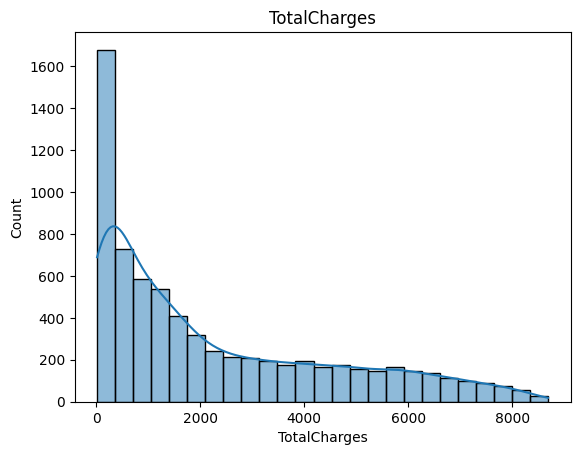

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

Observation:
- Customers with month-to-month contracts have a higher churn rate compared to yearly contracts.
- Customers using fiber optic internet have higher churn.
- Customers without online security and tech support are more likely to churn.
- Customers using electronic check payment method have higher churn.
- Paperless billing customers churn more.
- These categorical features are important for churn prediction.

## Categorical Features

In [32]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print("Column:", col)
    print(df[col].value_counts())
    print("----------------------")

Column: customerID
customerID
7590-VHVEG    1
0265-PSUAE    1
2956-GGUCQ    1
6008-NAIXK    1
5956-YHHRX    1
             ..
7874-ECPQJ    1
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
3186-AJIEK    1
Name: count, Length: 7032, dtype: int64
----------------------
Column: gender
gender
Male      3549
Female    3483
Name: count, dtype: int64
----------------------
Column: Partner
Partner
No     3639
Yes    3393
Name: count, dtype: int64
----------------------
Column: Dependents
Dependents
No     4933
Yes    2099
Name: count, dtype: int64
----------------------
Column: PhoneService
PhoneService
Yes    6352
No      680
Name: count, dtype: int64
----------------------
Column: MultipleLines
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64
----------------------
Column: InternetService
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64
----------------------
Column: Online

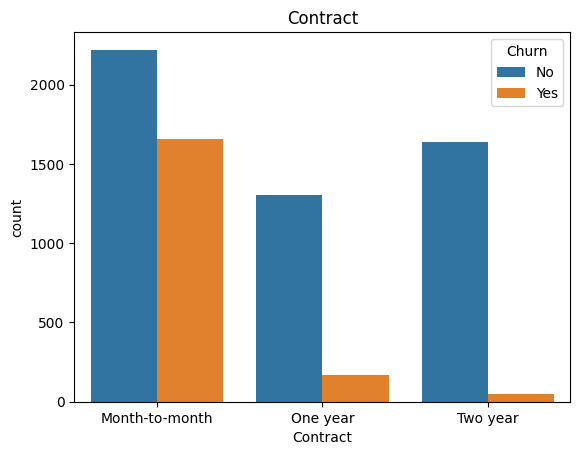

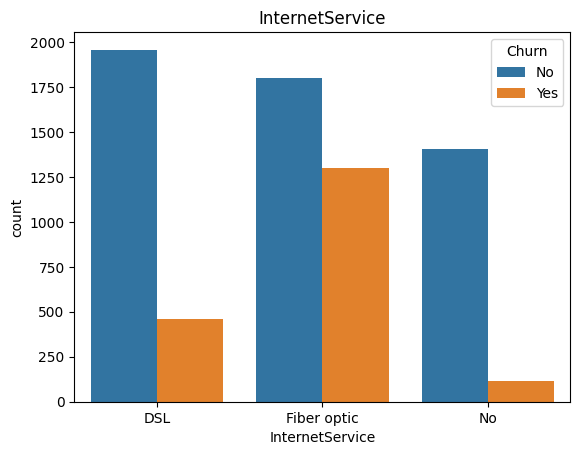

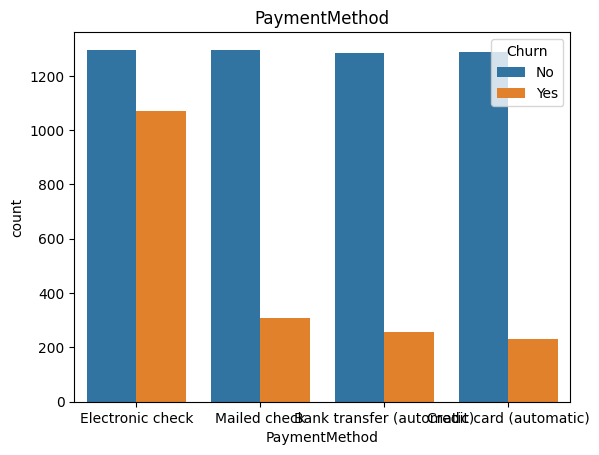

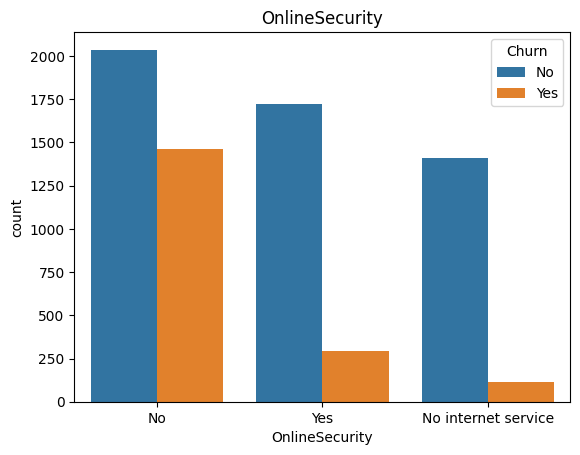

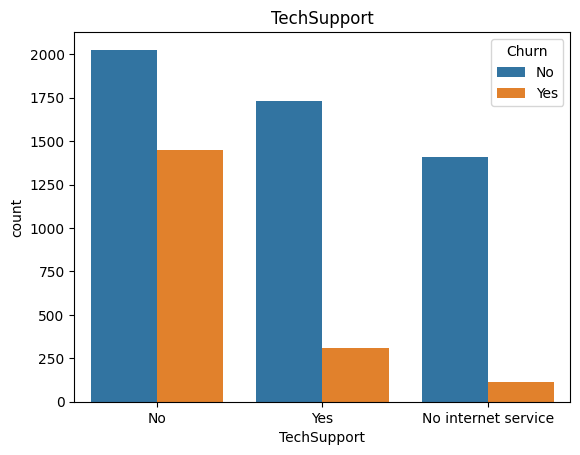

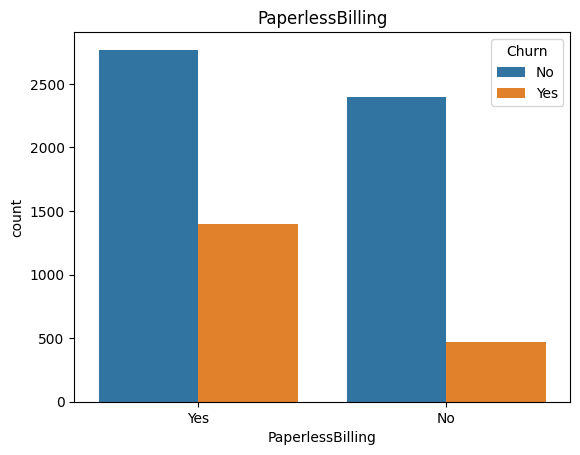

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

important_cat = ["Contract", "InternetService", "PaymentMethod", 
                 "OnlineSecurity", "TechSupport", "PaperlessBilling"]

for col in important_cat:
    sns.countplot(x=col, hue="Churn", data=df)
    plt.title(col)
    plt.show()

Observation:
- Customers with month-to-month contracts have a significantly higher churn rate compared to customers with one-year and two-year contracts.
- Customers using fiber optic internet service have higher churn compared to DSL and customers with no internet service.
- Customers using electronic check as a payment method have the highest churn rate compared to other payment methods.
- Customers who do not have online security are more likely to churn.
- Customers who do not have tech support are more likely to churn.
- Customers who use paperless billing tend to churn more than those who do not.
- Features such as Contract, InternetService, PaymentMethod, OnlineSecurity, TechSupport, and PaperlessBilling are important predictors of churn.

Additional Observation:
- The dataset contains many categorical features with multiple categories, so encoding will be required.
- Some features contain values like 'No internet service' and 'No phone service', which can be grouped with 'No' to reduce the number of categories.
- The dataset is dominated by customers with month-to-month contracts and fiber optic internet service.

## Correlation Heatmap

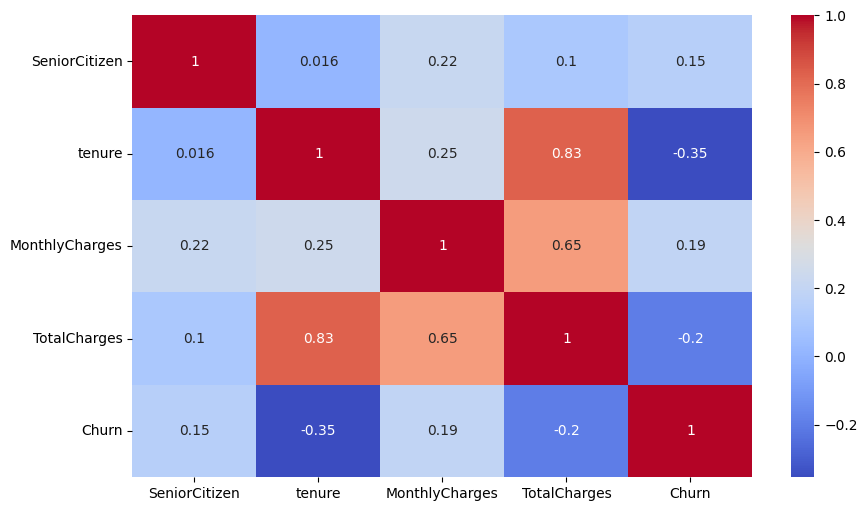

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert target first
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

# Select only numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

Observation:
- Tenure has a strong positive correlation with TotalCharges, indicating that customers with longer tenure have higher total charges.
- MonthlyCharges is moderately correlated with TotalCharges.
- SeniorCitizen has very low correlation with other numerical features.
- Numerical features alone do not strongly explain churn, so categorical features will play a major role in prediction.
- No severe multicollinearity issue, but TotalCharges is highly dependent on tenure, so we need to be careful while using both features.

EDA Summary:
- Dataset contains 7032 rows and 21 columns.
- Dataset is imbalanced (73% No churn, 27% Yes churn).
- Customers with month-to-month contracts churn more.
- Customers with fiber optic internet churn more.
- Customers paying via electronic check churn more.
- Customers without online security and tech support churn more.
- Customers with low tenure churn more.
- Customers with high monthly charges churn more.
- Categorical features are very important in predicting churn.

# Tenure vs Churn

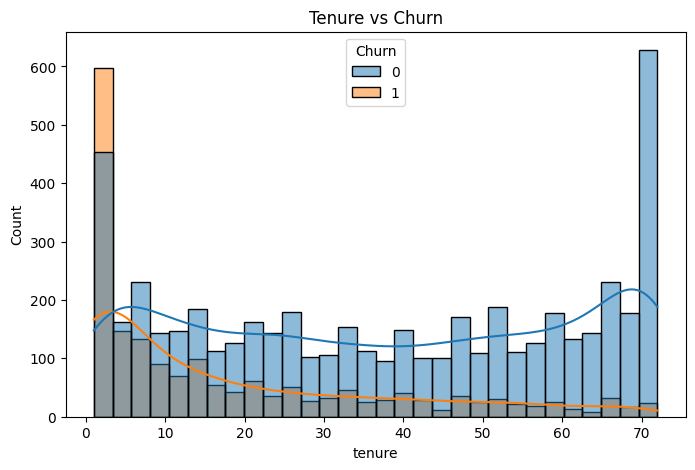

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True)
plt.title("Tenure vs Churn")
plt.show()

Observation:
- Customers with lower tenure are more likely to churn.

# MonthlyCharges vs Churn

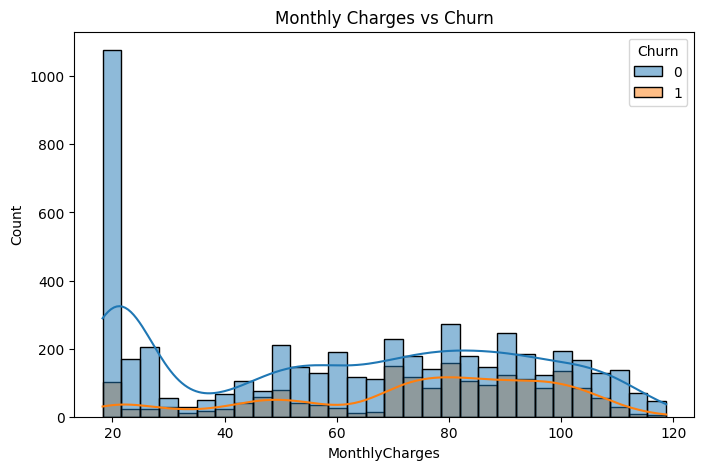

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", bins=30, kde=True)
plt.title("Monthly Charges vs Churn")
plt.show()

Observation:

- Customers with higher monthly charges have higher churn probability.

# TotalCharges vs Churn

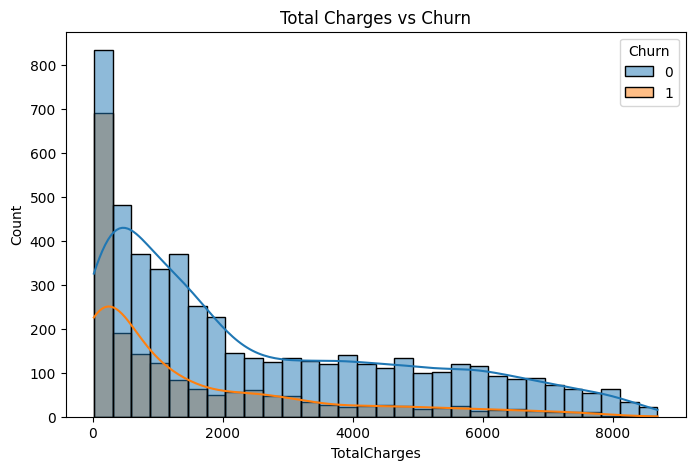

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="TotalCharges", hue="Churn", bins=30, kde=True)
plt.title("Total Charges vs Churn")
plt.show()

Observation:

- Customers with low total charges are more likely to churn (new customers).

# Contract vs Churn

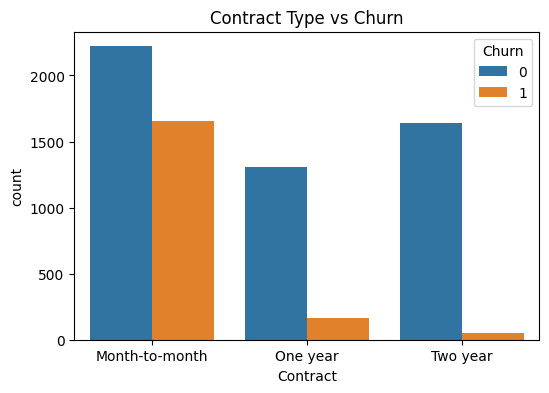

In [38]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Contract Type vs Churn")
plt.show()

Observation:

- Month-to-month contract customers churn significantly more than yearly contract customers.

# InternetService vs Churn

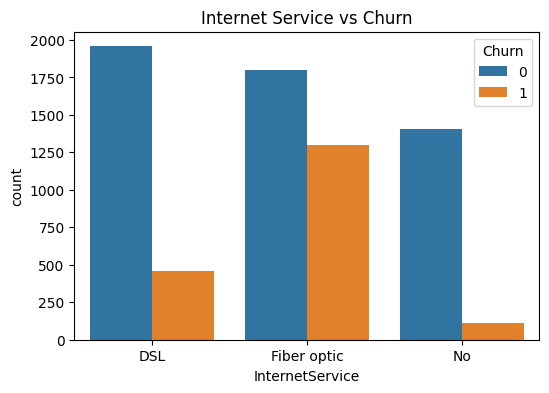

In [39]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Internet Service vs Churn")
plt.show()

Observation:

- Fiber optic users show higher churn compared to DSL users.

# PaymentMethod vs Churn

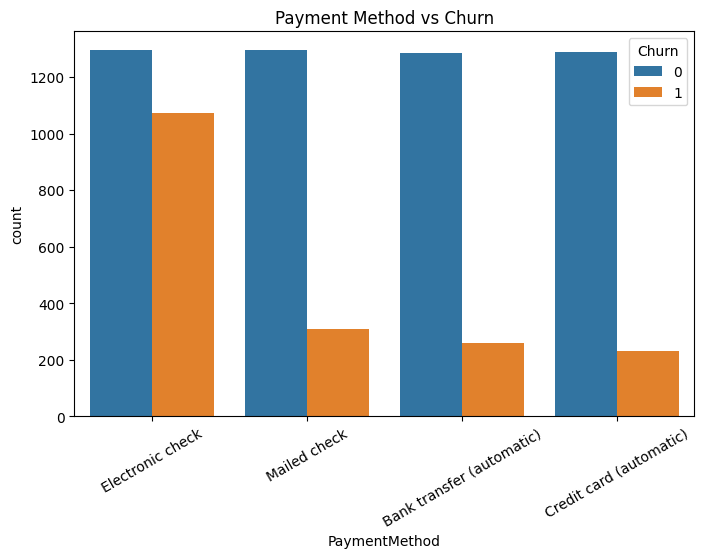

In [40]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.xticks(rotation=30)
plt.title("Payment Method vs Churn")
plt.show()

Observation:

- Customers using electronic check have the highest churn rate.

# TechSupport vs Churn

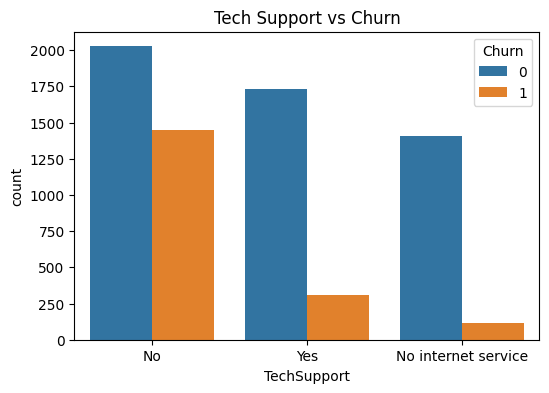

In [41]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="TechSupport", hue="Churn")
plt.title("Tech Support vs Churn")
plt.show()

Observation:

- Customers without tech support churn more.

# OnlineSecurity vs Churn

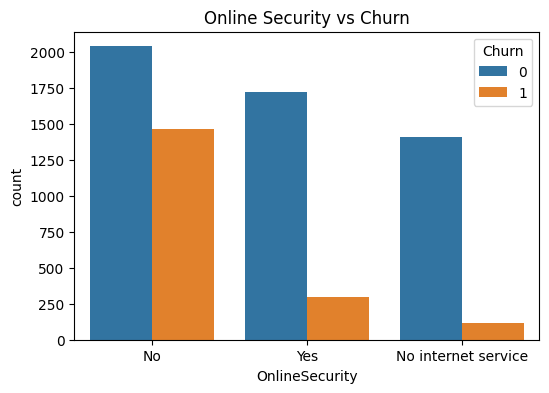

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="OnlineSecurity", hue="Churn")
plt.title("Online Security vs Churn")
plt.show()

Observation:

- Customers without online security have higher churn.

# Correlation with Churn

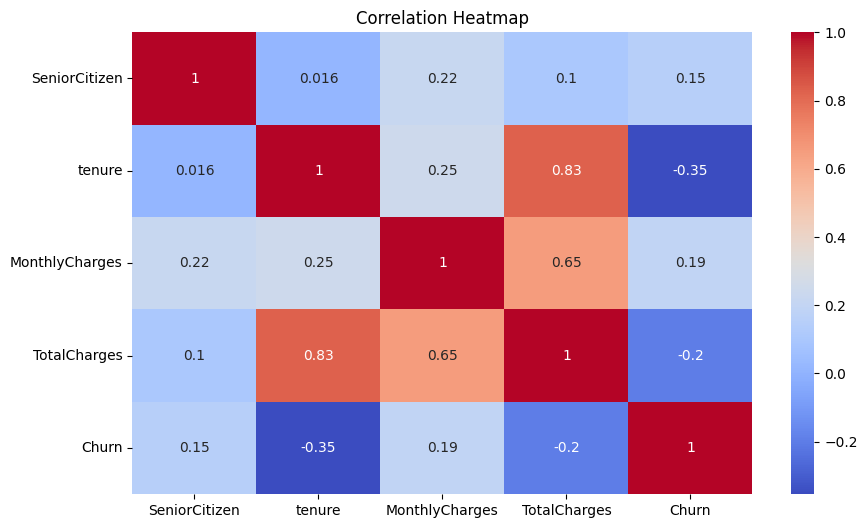

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Observation:

- Tenure and TotalCharges are strongly correlated. MonthlyCharges moderately affects churn.

# Boxplots

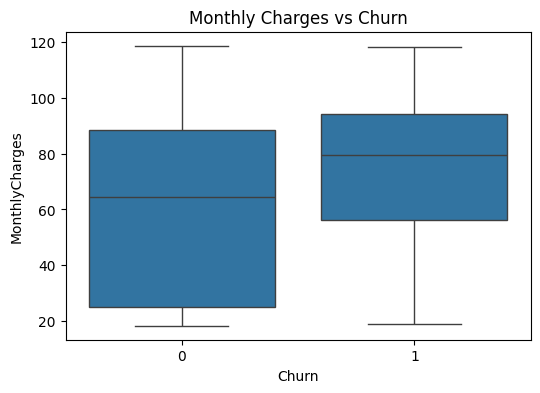

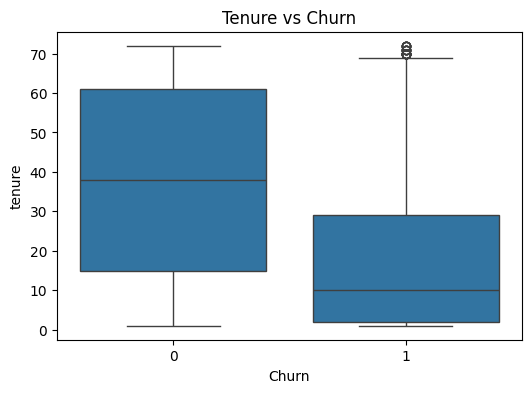

In [44]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure vs Churn")
plt.show()

# Churn Rate Plot

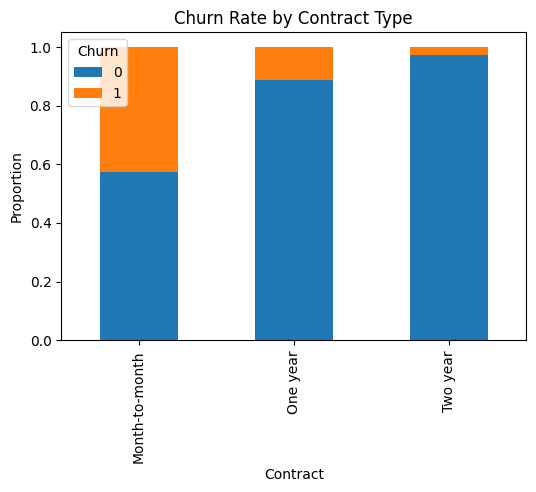

In [47]:
churn_rate = df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack()

churn_rate.plot(kind="bar", stacked=True, figsize=(6,4))
plt.title("Churn Rate by Contract Type")
plt.ylabel("Proportion")
plt.show()

Key Insights from EDA:

1. Customers with month-to-month contracts churn more.
2. Customers with fiber optic internet churn more.
3. Customers with higher monthly charges churn more.
4. Customers with low tenure churn more.
5. Customers without tech support churn more.
6. Customers using electronic check churn more.
7. Customers without online security churn more.

These insights were used for feature engineering.